In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)


In [30]:
df = pd.read_csv("../data/Medical_appointment_data.csv")

In [31]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (109593, 26)
Columns: ['specialty', 'appointment_time', 'gender', 'no_show', 'disability', 'place', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received']


,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


In [32]:
missing = df.isnull().mean().sort_values(ascending=False)
print("Missing value percentages:\n", missing)


Missing value percentages:
 age                            0.209502
specialty                      0.183652
disability                     0.151479
place                          0.105290
max_rain_day                   0.020649
average_rain_day               0.020485
max_temp_day                   0.020321
average_temp_day               0.020175
appointment_time               0.000000
no_show                        0.000000
over_60_years_old              0.000000
under_12_years_old             0.000000
appointment_shift              0.000000
gender                         0.000000
patient_needs_companion        0.000000
rainy_day_before               0.000000
storm_day_before               0.000000
rain_intensity                 0.000000
heat_intensity                 0.000000
appointment_date_continuous    0.000000
Hipertension                   0.000000
Diabetes                       0.000000
Alcoholism                     0.000000
Handcap                        0.000000
Scholarship 

In [33]:
print(df["place"].isnull().sum())
print(df["place"].unique())

11539
<ArrowStringArray>
[   'Lake Marvinville',             'ITAPEMA',              'ITAJAÍ',
           'Sarahside',          'Stokesfort',        'Deborahmouth',
                   nan,               'PENHA',           'Moranside',
         'North Aaron',
 ...
      'New Taylorfort',           'Ellisland',     'East Jacobmouth',
           'Hallburgh',            'Irwinton',     'Port Brenthaven',
 'West Patrickborough',    'West Gregoryport',       'Reynoldsville',
          'Wilcoxstad']
Length: 26290, dtype: str


In [34]:
df["place"] = df["place"].astype(str)

In [35]:
most_common_city = df["place"].mode()[0]
df["place"] = df["place"].fillna(most_common_city)

#df["place"] = df["place"].fillna("Unknown")

In [36]:
df["place"]

0         Lake Marvinville
1                  ITAPEMA
2                   ITAJAÍ
3                Sarahside
4                   ITAJAÍ
                ...       
109588              ITAJAÍ
109589     Port Georgestad
109590             Erinton
109591            CAMBORIU
109592              ITAJAÍ
Name: place, Length: 109593, dtype: str

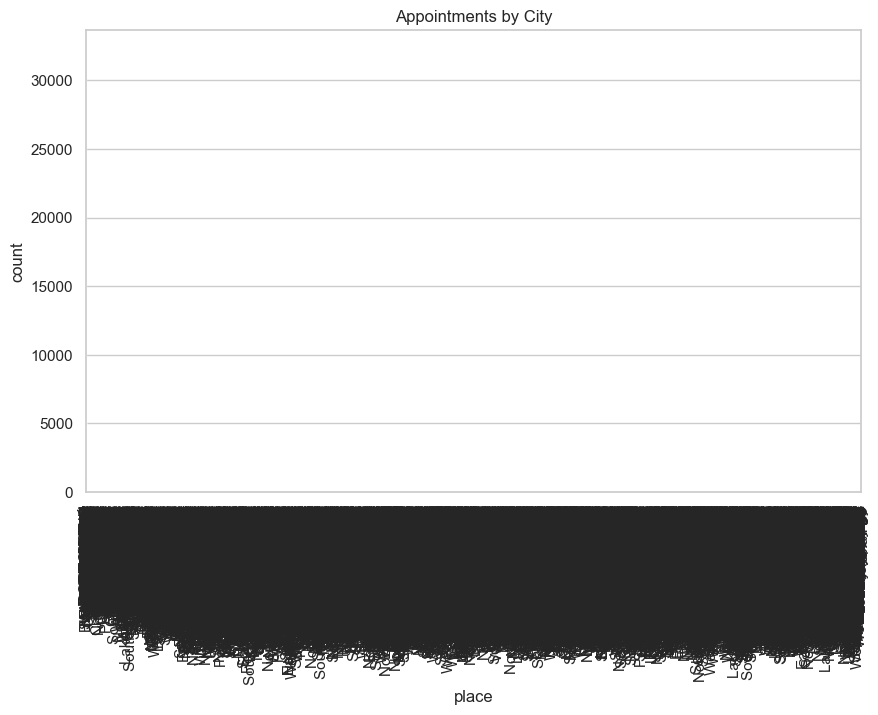

In [37]:
order = df["place"].value_counts().index.tolist()
sns.countplot(x="place", data=df, order=order)
plt.xticks(rotation=90)
plt.title("Appointments by City")
plt.show()

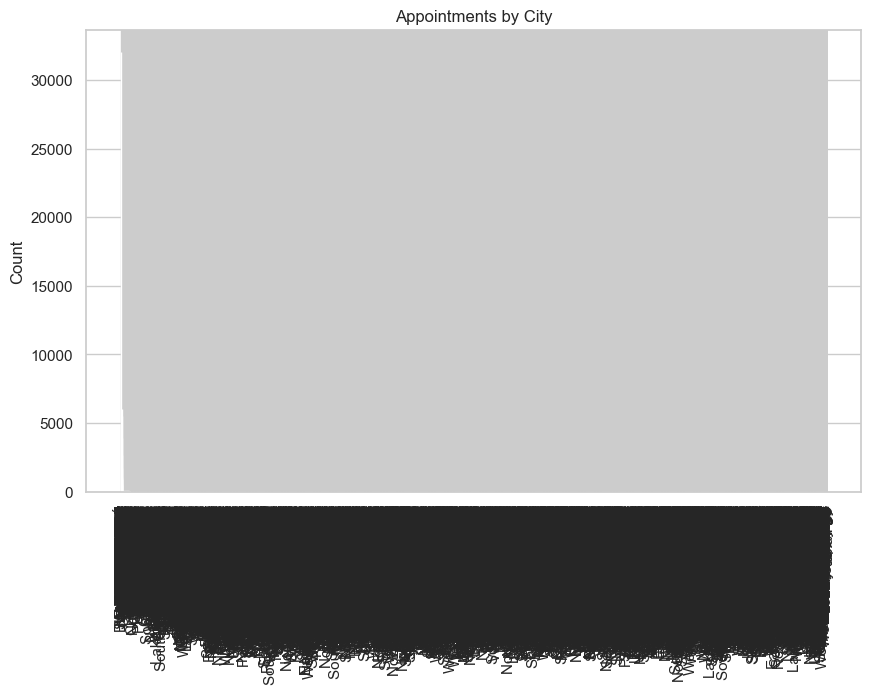

In [38]:
place_counts = df["place"].value_counts()

plt.figure(figsize=(10,6))
plt.bar(place_counts.index, place_counts.values, color="skyblue")
plt.xticks(rotation=90)
plt.title("Appointments by City")
plt.ylabel("Count")
plt.show()

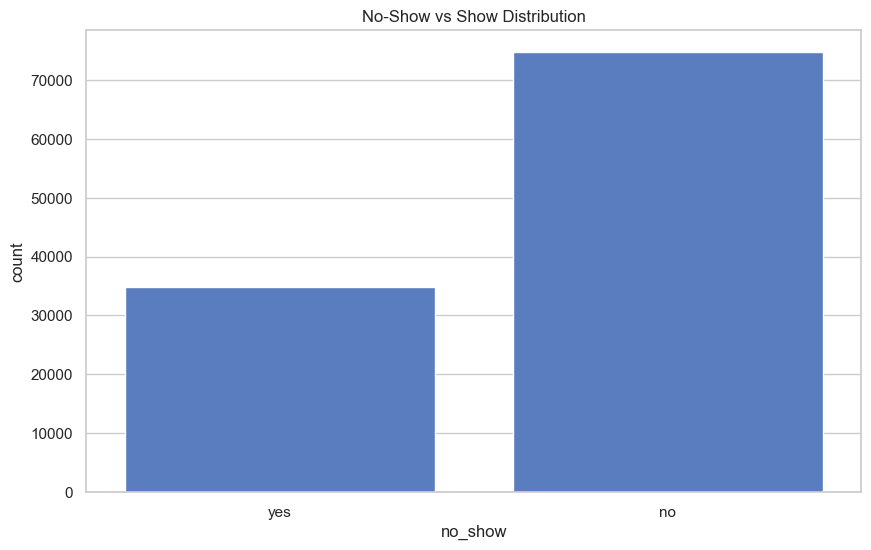

In [39]:
sns.countplot(x="no_show", data=df)
plt.title("No-Show vs Show Distribution")
plt.show()


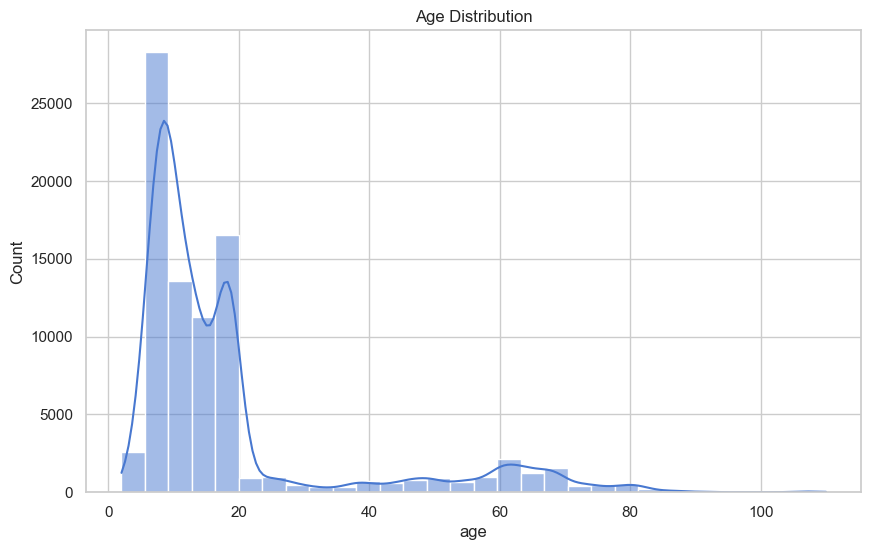

In [40]:
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


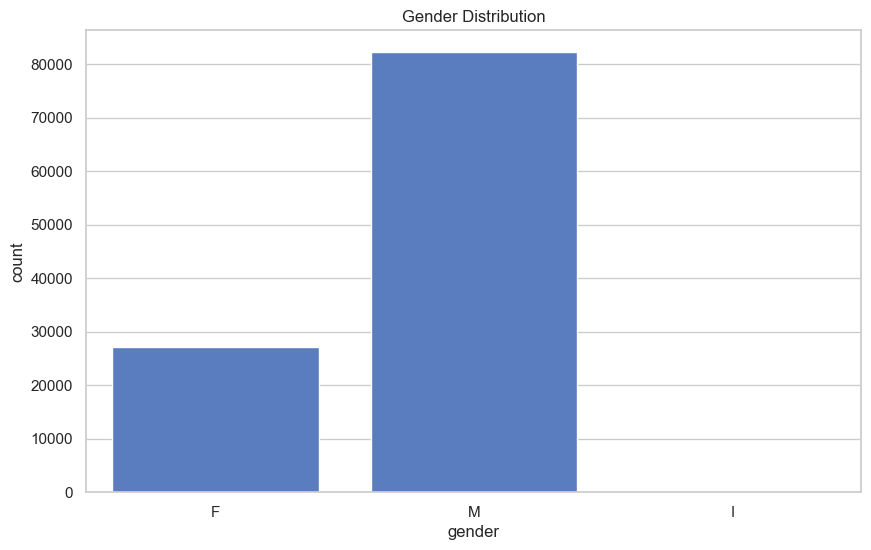

In [41]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()


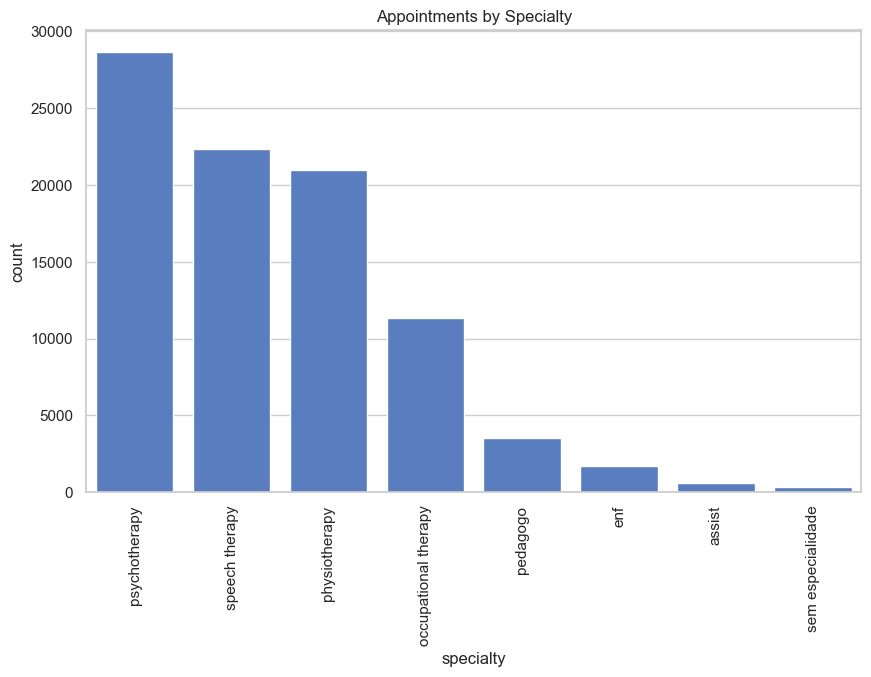

In [42]:
sns.countplot(x="specialty", data=df, order=df["specialty"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Appointments by Specialty")
plt.show()


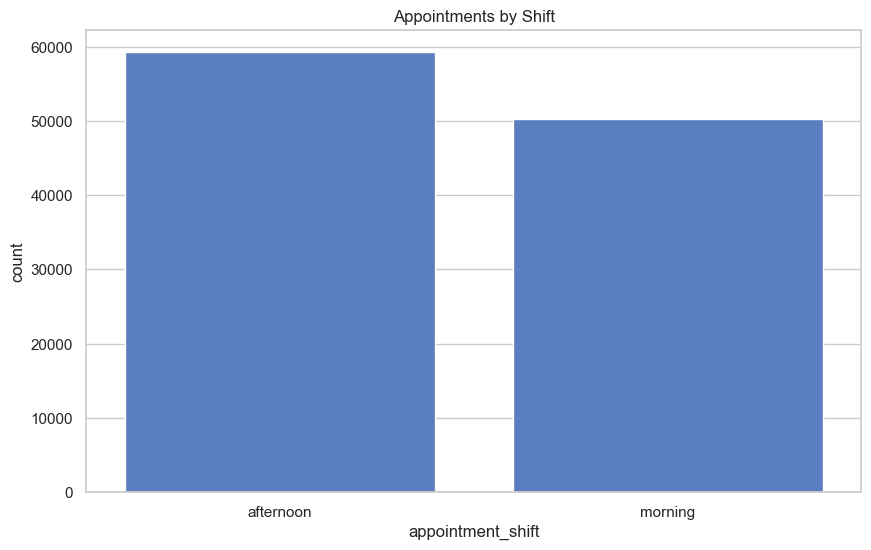

In [43]:
sns.countplot(x="appointment_shift", data=df)
plt.title("Appointments by Shift")
plt.show()


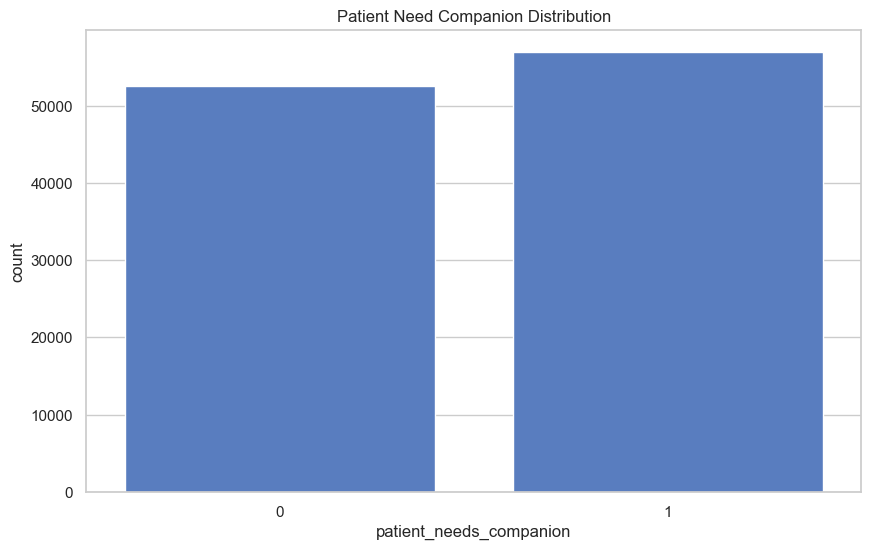

In [44]:
sns.countplot(x="patient_needs_companion", data=df)
plt.title("Patient Need Companion Distribution")
plt.show()


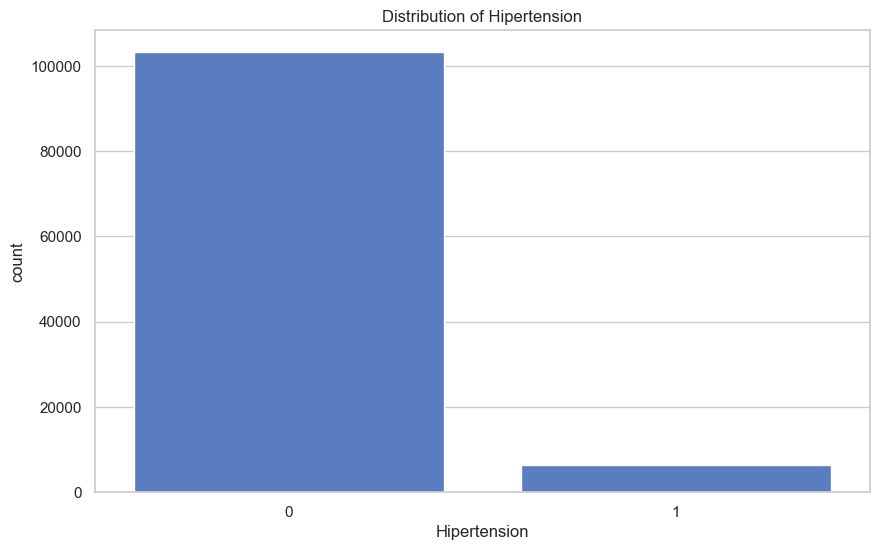

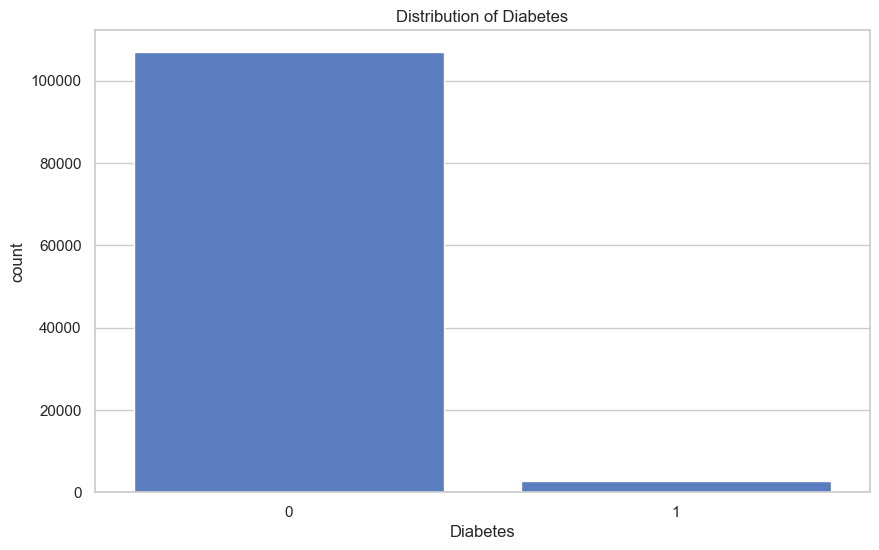

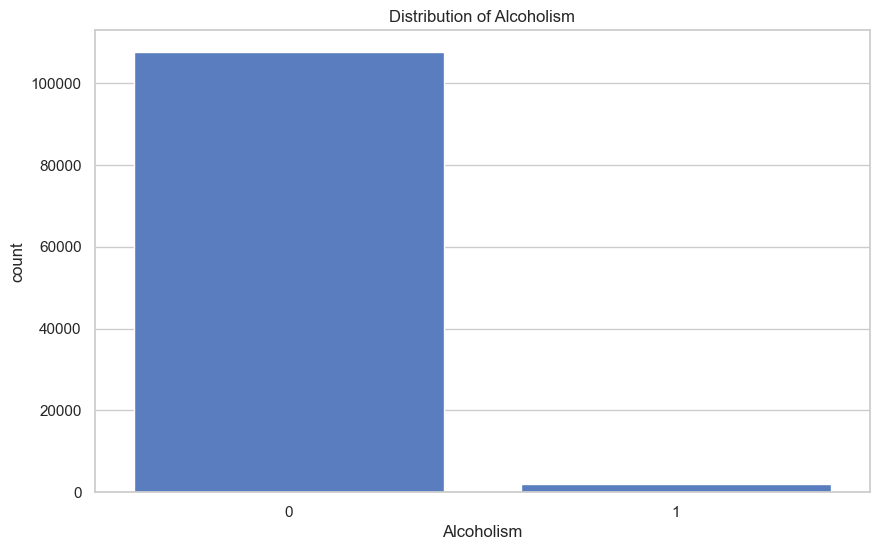

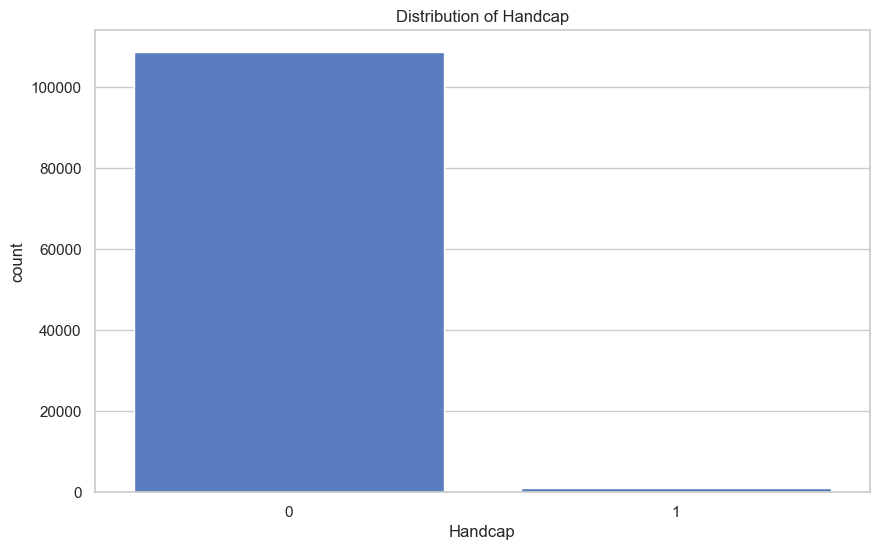

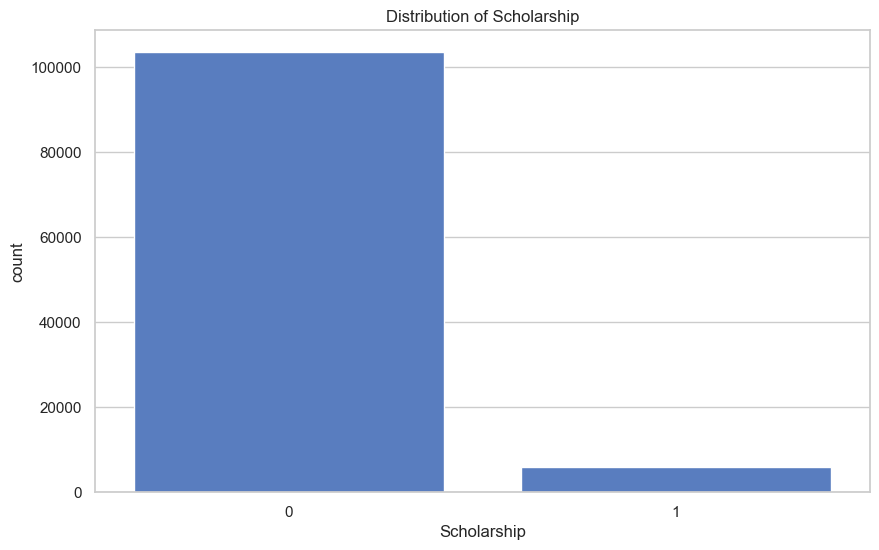

In [45]:
health_vars = ["Hipertension", "Diabetes", "Alcoholism", "Handcap", "Scholarship"]
for col in health_vars:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()


In [46]:
weather_vars = ["average_temp_day", "average_rain_day", "max_temp_day", "max_rain_day", "rainy_day_before", "storm_day_before"]
df[weather_vars].describe()


,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before
count,107382.000000,107348.000000,107366.000000,107330.000000,109593.000000,109593.000000
mean,20.346642,0.183537,24.032910,2.048093,0.937396,0.937533
std,3.446079,0.416267,3.959696,4.352247,0.242251,0.242004
min,8.940000,0.000000,13.300000,0.000000,0.000000,0.000000
25%,18.060000,0.000000,21.400000,0.000000,1.000000,1.000000
50%,20.600000,0.010000,23.900000,0.200000,1.000000,1.000000
75%,22.720000,0.150000,26.800000,1.900000,1.000000,1.000000
max,28.010000,4.770000,35.400000,45.000000,1.000000,1.000000


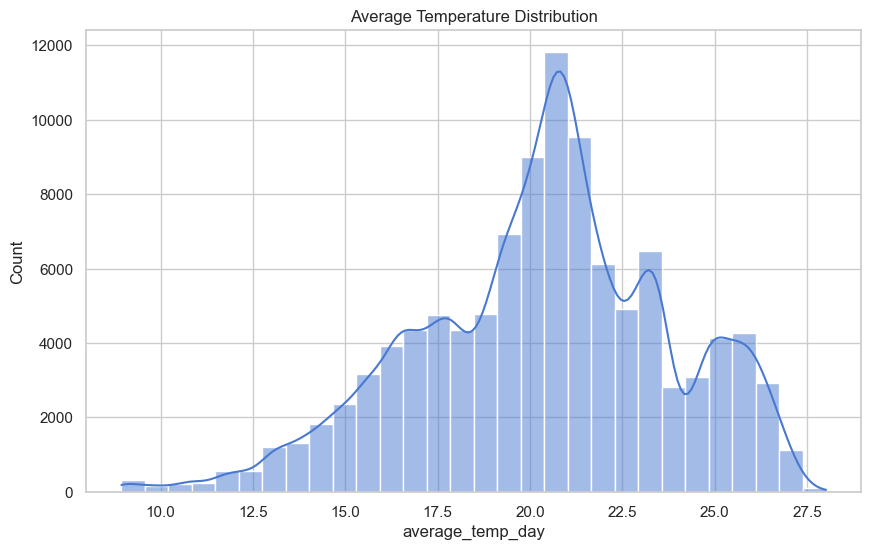

In [47]:
sns.histplot(df["average_temp_day"], bins=30, kde=True)
plt.title("Average Temperature Distribution")
plt.show()


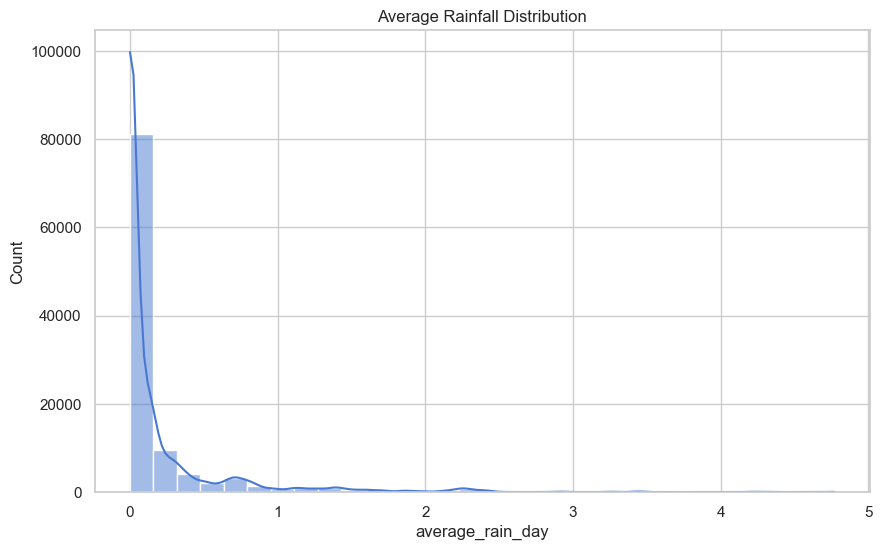

In [48]:
sns.histplot(df["average_rain_day"], bins=30, kde=True)
plt.title("Average Rainfall Distribution")
plt.show()


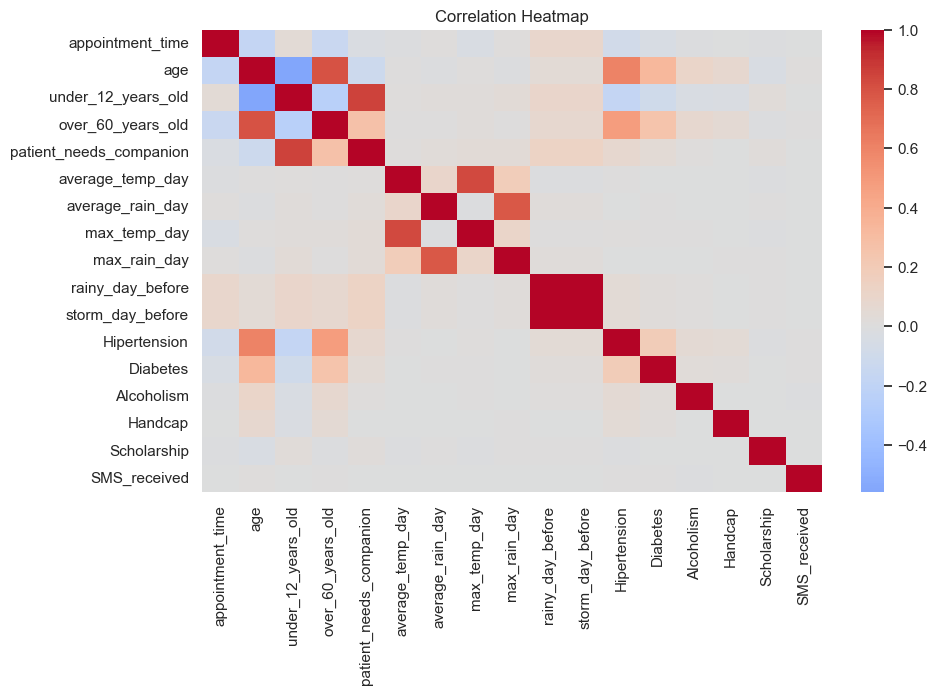

In [50]:
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()



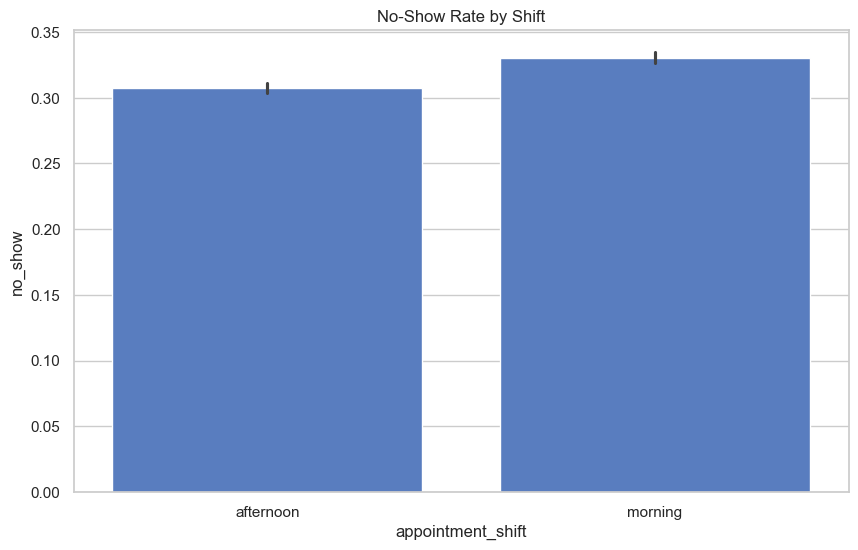

In [51]:
sns.barplot(x="appointment_shift", y=df["no_show"].map({"yes":1,"no":0}), data=df)
plt.title("No-Show Rate by Shift")
plt.show()


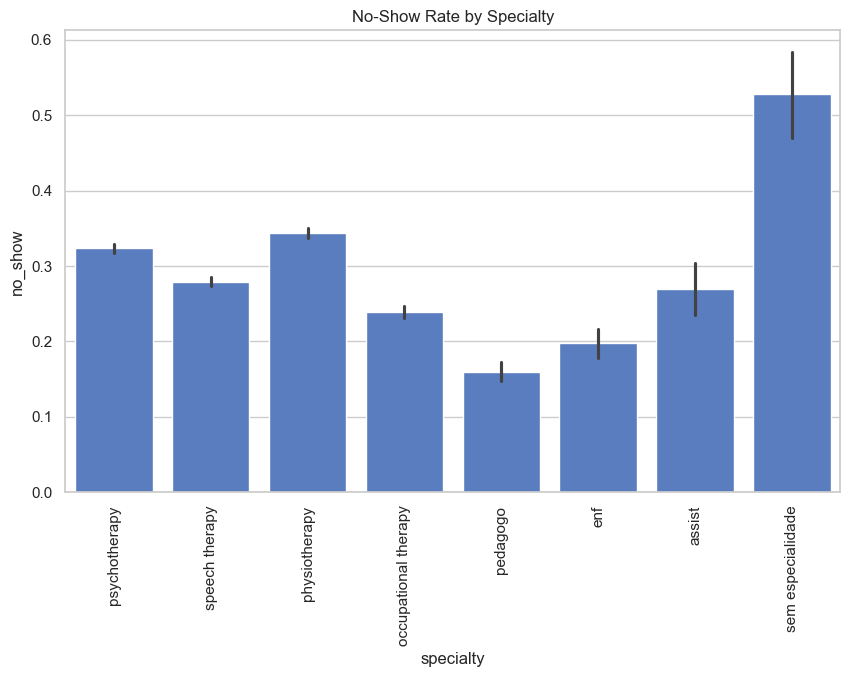

In [52]:
sns.barplot(x="specialty", y=df["no_show"].map({"yes":1,"no":0}), data=df,
            order=df["specialty"].value_counts().index)
plt.xticks(rotation=90)
plt.title("No-Show Rate by Specialty")
plt.show()


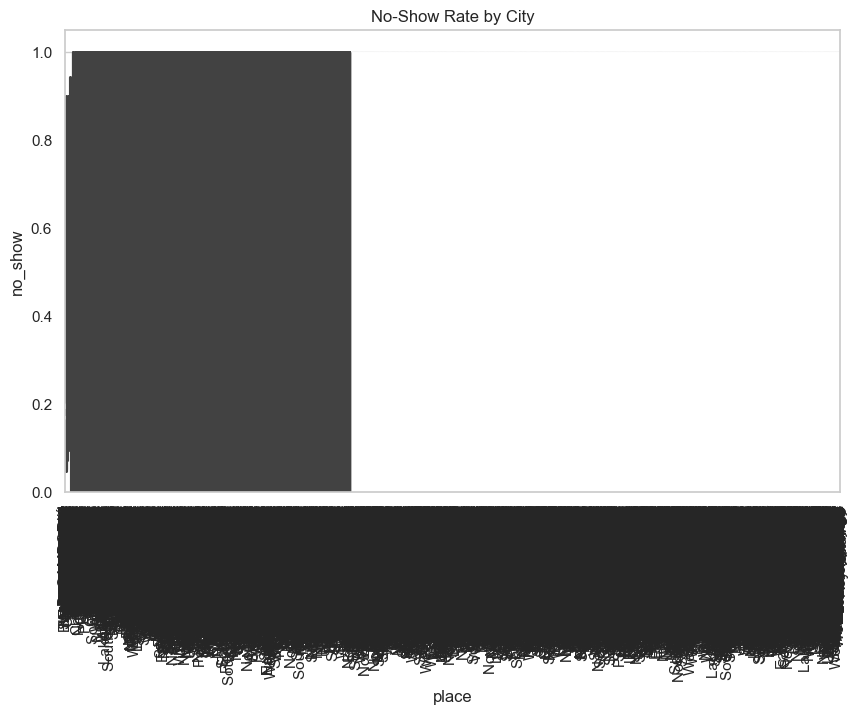

In [53]:
sns.barplot(x="place", y=df["no_show"].map({"yes":1,"no":0}), data=df,
            order=df["place"].value_counts().index)
plt.xticks(rotation=90)
plt.title("No-Show Rate by City")
plt.show()
